<a href="https://colab.research.google.com/github/enzosakamoto/ecm514-projeto-I/blob/main/src/IMT_Projeto_S1_enzo_joao_pedro_rafael_vitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploratory Data Analysis (EDA)**
##Análise sobre saneamento básico e sua relação com os resultados do ENEM 2020

In [31]:
#@title **Identificação do Grupo**

Aluno1 = 'Enzo Yuji Sakamoto, 21.00210-0' #@param {type:"string"}
Aluno2 = 'João Vitor Choueri Branco, 21.01075-7' #@param {type:"string"}
Aluno3 = 'Pedro Henrique de Sousa Matumoto, 21.00784-5' #@param {type:"string"}
Aluno4 = 'Rafael Rubio Carnes, 20.00611-0' #@param {type:"string"}
Aluno5 = 'Vitor Guirão Soller, 21.01444-2' #@param {type:"string"}





# Importação de bibliotecas


# **Resumo (*Abstract*)** 🏗️🏗️

O seguinte projeto estuda os dados fornecido pelo Sistema Nacional de Informações sobre Saneamento (SNIS) e a suas relações com o resultado do ENEM 2020. Primeiramente foi necessário cruzar a base, constatando que cerca de XX% dos dados não poderiam ser utilizados por não contarem com o munícipio. Após isto, foram realizados diversos cortes



# **Introdução**

O saneamento básico, segundo a [Agência Nacional de Águas e Saneamento Básico (ANA)](https://www.gov.br/ana/pt-br/assuntos/saneamento-basico/saneamento-basico-no-brasil/panorama-do-saneamento-no-brasil-1#:~:text=O%20saneamento%20básico%20compreende%20os,manejo%20da%20água%20das%20chuvas), abrange o abastecimento de água, coleta e tratamento de esgotos, limpeza urbana, destinação do lixo e drenagem das águas pluviais. Trata-se de um direito fundamental do cidadão e um pilar essencial para a saúde pública, a qualidade de vida e o desenvolvimento social. No entanto, o Brasil ainda enfrenta grandes desafios nesse setor, com milhões de pessoas vivendo em municípios com acesso precário ou inexistente a esses serviços.

A literatura e reportagens recentes apontam que a ausência de saneamento básico impacta não apenas a saúde, mas também o desempenho escolar, ampliando desigualdades sociais e educacionais. Diante desse contexto, este projeto busca analisar, de forma estatística e exploratória, como diferentes aspectos do saneamento básico se relacionam com o desempenho dos alunos no ENEM 2020, utilizando dados oficiais do Sistema Nacional de Informações sobre Saneamento (SNIS) e dos microdados do ENEM.

O objetivo central é investigar se a infraestrutura de saneamento influencia as oportunidades educacionais, especialmente em um exame nacional de grande relevância como o ENEM. Para isso, o trabalho foi estruturado em torno de cinco perguntas principais:

- **Q1:** A cobertura de abastecimento de água nos municípios explica diferenças na nota média de redação dos alunos do ENEM 2020?
- **Q2:** Municípios com altas perdas na distribuição de água apresentam menor taxa de comparecimento ao exame do ENEM?
- **Q3:** Existe diferença estatisticamente significativa na média das notas de Matemática entre alunos de municípios com índice de atendimento total de água acima ou abaixo da mediana nacional?
- **Q4:** Há associação estatística entre o tipo de abastecimento de água na residência do aluno (informado no questionário socioeconômico) e o índice de atendimento total de água do município?
- **Q5:** Como se comportam os intervalos de confiança das médias das notas de Matemática ao comparar municípios com os 25% melhores e 25% piores índices de tratamento de esgoto?

Cada uma dessas questões é abordada ao longo do notebook, com análises estatísticas, visualizações e discussões fundamentadas em referências externas. Ao final, o trabalho busca contribuir para o debate sobre a importância de políticas públicas que promovam o acesso universal ao saneamento como estratégia para a redução das desigualdades educacionais no Brasil.

# **Descrição e origem dos dados**

## Os dados foram retirados de fontes oficiais do governo

### Sistema Nacional de Informações sobre Saneamento (SNIS)
https://basedosdados.org/dataset/2a543ad8-3cdb-4047-9498-efe7fb8ed697?table=df7cf198-4889-4baf-bb77-4e0e28eb90ca

O SNIS é uma unidade vinculada à Secretaria Nacional de Saneamento (SNS) do Ministério do Desenvolvimento Regional (MDR). Essa tabela contém informações e indicadores consolidados por município referentes aos serviços de água e esgoto, proporcionando um panorama detalhado do histórico e do estado do saneamento básico no Brasil. Os dados são provenientes da Série Histórica de Municípios e abrangem o período de 1995 a 2022.

Para o seguinte projeto, foram recortados os dados do ano de 2020.

### ENEM
https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem
Os microdados são provenientes do Exame Nacional do Ensino Médio (Enem), uma iniciativa do Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira (Inep), que é vinculada ao Ministério da Educação (MEC).

Esses microdados representam o menor nível de desagregação de dados recolhidos por meio do exame. Eles incluem informações detalhadas como as provas aplicadas, os gabaritos, dados sobre os itens das questões, as notas dos participantes e o questionário socioeconômico respondido pelos inscritos no Enem. Os microdados do Enem estão disponíveis para consulta e uso desde o ano de 1998 até 2023.

Para o seguinte projeto, foram recortados os dados do ano de 2020.

### Cruzamento dentre os dados do ENEM e do SNIS
Para cruzamento foi com base no município o estados, portanto as análises foram feitas sobre isso.


### Localização dos dados

Como ambas as bases precisam ser baixadas de formas manual, salvamos no diretório `/work` em nosso repositório para garantir que o *notebook* seja totalmente executável







In [1]:
import pandas as pd
import numpy as np
from pprint import pprint
from pandas import ExcelFile
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# **Aquisição e Preparação dos dados**

Faça aqui a aquisição dos dados, justificando e incluindo aqui eventuais reduções as efetuadas.

Não deixe de descrever e justificar reduções (seleções) feitas nos dados originais para os seus propósitos (por exemplo, selecionou somente dados do último ano, somente dados de países da América Latina ou selecionou somente algumas tabelas dentre várias tabelas disponíveis).








## Mapeamento da tradução dos microdados


In [2]:
path = "https://ecm514-projeto-1.s3.us-east-1.amazonaws.com"
# for local debug
# path = "./datasets"

In [3]:
micro_dados = ExcelFile(f"{path}/Dicionario_Microdados_Enem_2020.xlsx").sheet_names[
    1:-1
]

pprint(micro_dados)

[]


In [5]:
import os
import urllib.request

url = "https://ecm514-projeto-1.s3.us-east-1.amazonaws.com/MICRODADOS_ENEM_2020.csv"
filename = "MICRODADOS_ENEM_2020.csv"

if not os.path.exists(filename):
    print("Baixando arquivo...")
    urllib.request.urlretrieve(url, filename)
    print("Download concluído.")
else:
    print("Arquivo já existe, não será baixado novamente.")

Baixando arquivo...
Download concluído.
Download concluído.


## Leitura traduções


In [7]:
df_micro_dados = {
    planilha: pd.read_excel(
        f"Dicionario_Microdados_Enem_2023.xlsx",
        sheet_name=planilha,
        header=0,
    )
    for planilha in micro_dados
}

pprint(list(df_micro_dados.keys()))

[]


## Leitura dos microdados


In [6]:
MAXIMO = 200_000 # Utilizado para debug e testes mais rápidos

df = pd.read_csv(
    "./MICRODADOS_ENEM_2020.csv", sep=";", encoding="ISO-8859-1"
)

df.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,200006271946,2020,11,F,1,2,1,1,11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200001195856,2020,11,M,2,3,1,1,11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,200001943954,2020,4,F,2,3,2,2,0,2,...,B,A,A,B,A,A,A,A,A,A
3,200001908998,2020,2,M,1,3,1,2,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,200001634757,2020,4,F,1,3,2,1,1,1,...,A,A,A,B,A,B,B,A,A,B


### Drop de colunas desnecessárias


In [8]:
df.drop(
    columns=[
        # Dados da prova objetiva
        "CO_PROVA_CN",
        "CO_PROVA_CH",
        "CO_PROVA_LC",
        "CO_PROVA_MT",
        "TX_RESPOSTAS_CN",
        "TX_RESPOSTAS_CH",
        "TX_RESPOSTAS_LC",
        "TX_RESPOSTAS_MT",
        "TX_GABARITO_CN",
        "TX_GABARITO_CH",
        "TX_GABARITO_LC",
        "TX_GABARITO_MT",
        # Dados da redação
        "NU_NOTA_COMP1",
        "NU_NOTA_COMP2",
        "NU_NOTA_COMP3",
        "NU_NOTA_COMP4",
        "NU_NOTA_COMP5",
    ],
    inplace=True,
)

## Cruzamento das traduções com os microdados


In [9]:
# Dropar linhas com CO_MUNICIPIO_ESC nulo
df = df.dropna(subset=["CO_MUNICIPIO_ESC", "CO_MUNICIPIO_PROVA", "CO_UF_ESC", "CO_UF_PROVA"])

df.shape

(904569, 59)

In [11]:
df_saneamento = pd.read_csv(f"{path}/br_mdr_snis_municipio_agua_esgoto.csv")

df_saneamento = df_saneamento[df_saneamento.ano == 2020].reset_index(drop=True)

df_saneamento.columns = df_saneamento.columns.str.upper()

df_saneamento.head()

,ANO,ID_MUNICIPIO,SIGLA_UF,POPULACAO_ATENDIDA_AGUA,POPULACAO_ATENTIDA_ESGOTO,POPULACAO_URBANA,POPULACAO_URBANA_RESIDENTE_AGUA,POPULACAO_URBANA_ATENDIDA_AGUA,POPULACAO_URBANA_ATENDIDA_AGUA_IBGE,POPULACAO_URBANA_RESIDENTE_ESGOTO,...,INVESTIMENTO_RECURSO_ONEROSO_MUNICIPIO,INVESTIMENTO_RECURSO_NAO_ONEROSO_MUNICIPIO,INVESTIMENTO_TOTAL_MUNICIPIO,INVESTIMENTO_AGUA_ESTADO,INVESTIMENTO_ESGOTO_ESTADO,INVESTIMENTO_OUTRO_ESTADO,INVESTIMENTO_RECURSO_PROPRIO_ESTADO,INVESTIMENTO_RECURSO_ONEROSO_ESTADO,INVESTIMENTO_RECURSO_NAO_ONEROSO_ESTADO,INVESTIMENTO_TOTAL_ESTADO
0,2020,2905107,BA,6942.0,547.0,3193.0,3193.0,3193.0,9058.0,3193.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020,2909505,BA,3632.0,2763.0,3376.0,3376.0,3336.0,5351.0,3376.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020,2910750,BA,16076.0,8000.0,6992.0,6992.0,6975.0,17845.0,6992.0,...,NaN,NaN,228725.81,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020,2915106,BA,9516.0,12242.0,9577.0,9577.0,9516.0,12242.0,9577.0,...,NaN,NaN,74000.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2020,2917607,BA,41625.0,15885.0,41639.0,41639.0,41625.0,54673.0,41639.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Munícipios que tiveram prova do ENEM mas que não estão na pesquisa


In [12]:
df.CO_MUNICIPIO_PROVA.nunique()

1747

In [13]:
df_saneamento.ID_MUNICIPIO.nunique()

5338

In [14]:
df.CO_MUNICIPIO_PROVA.nunique() - df_saneamento.ID_MUNICIPIO.nunique()

-3591

In [49]:
df[~df.CO_MUNICIPIO_PROVA.isin(df_saneamento.ID_MUNICIPIO)]

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
2205,200002145149,2020,2,F,1,3,1,2,0,2,...,A,A,A,B,A,A,C,A,B,A
3210,200001431391,2020,2,M,1,2,1,2,0,2,...,A,A,A,B,A,A,D,A,A,B
4288,200003055872,2020,2,M,1,2,1,2,0,2,...,A,A,A,B,A,A,C,A,B,B
5077,200001534216,2020,5,M,1,2,1,2,0,2,...,A,A,A,B,A,A,D,A,B,B
5273,200003016508,2020,2,F,1,3,1,2,0,2,...,B,A,A,B,A,B,B,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5778359,200002999270,2020,4,M,1,3,1,2,0,2,...,A,A,A,B,B,A,B,A,A,B
5779783,200006488798,2020,3,M,1,5,1,2,0,2,...,A,A,A,A,A,A,A,A,A,A
5782185,200001102302,2020,9,M,1,2,1,2,0,2,...,B,A,A,B,A,A,C,A,A,B
5782587,200003945158,2020,10,M,1,3,1,2,0,2,...,A,A,A,B,A,A,B,A,A,A


In [43]:
df[~df.CO_MUNICIPIO_PROVA.isin(df_saneamento.ID_MUNICIPIO)].shape[0] / df.shape[0] * 100

0.7858991409168344

In [50]:
df[df.CO_MUNICIPIO_PROVA.isin(df_saneamento.ID_MUNICIPIO)].shape[0] / df.shape[0] * 100

99.21410085908316

In [53]:
print("Percentual de municípios com saneamento básico:", end=" ")
print(
    df[df.CO_MUNICIPIO_PROVA.isin(df_saneamento.ID_MUNICIPIO)].shape[0]
    / df.shape[0]
    * 100, "%"
)

Percentual de municípios com saneamento básico: 99.21410085908316 %


# **Análises** 🏗️

Antes de iniciar as análises, é importante ter em mente que esses dados, apesar de oficias, não são totalmente completos. Muitos muníc


# Q1. A cobertura de abastecimento de água (indice_atendimento_total_agua) explica diferenças na nota média de redação?


In [17]:
df_calculo_morador = df.copy()

df_calculo_morador = df_calculo_morador[df_calculo_morador["CO_MUNICIPIO_ESC"] != 0]
df_calculo_morador = df_calculo_morador[df_calculo_morador["IN_TREINEIRO"] == 0]
df_calculo_morador = df_calculo_morador[df_calculo_morador["TP_STATUS_REDACAO"] == 1]
df_calculo_morador = df_calculo_morador[df_calculo_morador["TP_PRESENCA_CN"] == 1]
df_calculo_morador = df_calculo_morador[df_calculo_morador["TP_PRESENCA_CH"] == 1]
df_calculo_morador = df_calculo_morador[df_calculo_morador["TP_PRESENCA_LC"] == 1]
df_calculo_morador = df_calculo_morador[df_calculo_morador["TP_PRESENCA_MT"] == 1]

nota_cols = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

df_calculo_morador.dropna(subset=nota_cols, inplace=True)

df_calculo_morador["NU_NOTA_TOTAL_INDIVIDUAL"] = df_calculo_morador[nota_cols].sum(
    axis=1
)

df_agregado_municipio = (
    df_calculo_morador.groupby(["CO_MUNICIPIO_ESC", "NO_MUNICIPIO_ESC"])
    .agg(
        SOMA_NOTAS_TOTAIS_MUNICIPIO=("NU_NOTA_TOTAL_INDIVIDUAL", "sum"),
        POPULACAO_CALCULO=("NU_INSCRICAO", "nunique")
    )
    .reset_index()
)

df_final_morador = df_agregado_municipio[df_agregado_municipio["POPULACAO_CALCULO"] > 0].copy()

df_final_morador["SOMA_NOTAS_POR_MORADOR"] = (
    df_final_morador["SOMA_NOTAS_TOTAIS_MUNICIPIO"]
    / df_final_morador["POPULACAO_CALCULO"]
)


df_final_morador["SOMA_NOTAS_POR_MORADOR"] = (
    df_final_morador["SOMA_NOTAS_POR_MORADOR"] / 4
)

df_final_morador = df_final_morador.merge(
    df_saneamento,
    left_on="CO_MUNICIPIO_ESC",
    right_on="ID_MUNICIPIO",
    how="inner",
)

df_final_morador


,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,SOMA_NOTAS_TOTAIS_MUNICIPIO,POPULACAO_CALCULO,SOMA_NOTAS_POR_MORADOR,ANO,ID_MUNICIPIO,SIGLA_UF,POPULACAO_ATENDIDA_AGUA,POPULACAO_ATENTIDA_ESGOTO,...,INVESTIMENTO_RECURSO_ONEROSO_MUNICIPIO,INVESTIMENTO_RECURSO_NAO_ONEROSO_MUNICIPIO,INVESTIMENTO_TOTAL_MUNICIPIO,INVESTIMENTO_AGUA_ESTADO,INVESTIMENTO_ESGOTO_ESTADO,INVESTIMENTO_OUTRO_ESTADO,INVESTIMENTO_RECURSO_PROPRIO_ESTADO,INVESTIMENTO_RECURSO_ONEROSO_ESTADO,INVESTIMENTO_RECURSO_NAO_ONEROSO_ESTADO,INVESTIMENTO_TOTAL_ESTADO
0,1100015.0,Alta Floresta D'Oeste,164790.1,62,664.476210,2020,1100015,RO,10716.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1100023.0,Ariquemes,668320.0,255,655.215686,2020,1100023,RO,92761.0,2280.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1100031.0,Cabixi,7383.3,3,615.275000,2020,1100031,RO,2332.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1100049.0,Cacoal,791163.6,290,682.037586,2020,1100049,RO,67689.0,46252.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1100056.0,Cerejeiras,87485.6,35,624.897143,2020,1100056,RO,10284.0,13821.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5184,5221908.0,Varjão,14729.6,6,613.733333,2020,5221908,GO,2394.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5185,5222005.0,Vianópolis,75402.7,29,650.023276,2020,5222005,GO,10262.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5186,5222203.0,Vila Boa,15242.8,7,544.385714,2020,5222203,GO,4532.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5187,5222302.0,Vila Propício,31511.8,13,605.996154,2020,5222302,GO,1719.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
def plot_scatter(df: pd.DataFrame, x: str, y: str, ylabel: str) -> None:
    cols = [x, y]
    df_plot = df[cols].apply(pd.to_numeric, errors="coerce").dropna()

    X = df_plot[x]
    Y = df_plot[y]

    slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
    line_x = np.linspace(X.min(), X.max(), 200)
    line_y = intercept + slope * line_x

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(X, Y, alpha=0.2, edgecolor="k", label="Municipios")
    ax.plot(
        line_x,
        line_y,
        color="red",
        linewidth=2,
        label=f"y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r_value**2:.3f}",
    )

    ax.plot(
        [0, 100],
        [intercept, intercept],
        color="yellow",
        linestyle="--",
        linewidth=1.5,
        label=f"y = {intercept:.2f}",
    )

    y_final = slope * 100 + intercept

    ax.annotate(
        "",
        xy=(100, y_final),
        xytext=(100, intercept),
        arrowprops=dict(arrowstyle="<->", color="orange", linewidth=2),
    )

    # Texto explicativo à esquerda da linha vertical
    ax.text(
        95,
        (intercept),
        f"Diferença média na pontuação\nsem e com saneamento:\n{int(slope * 100)} pontos",
        fontsize=10,
        va="center",
        ha="right",
        bbox=dict(
            boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8
        ),
    )

    ax.set_xlim(0, 100)
    ax.set_xlabel("Índice de atendimento total de água (%)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Cobertura de água vs. {ylabel}", fontsize=14, pad=12)
    ax.legend(frameon=False)
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

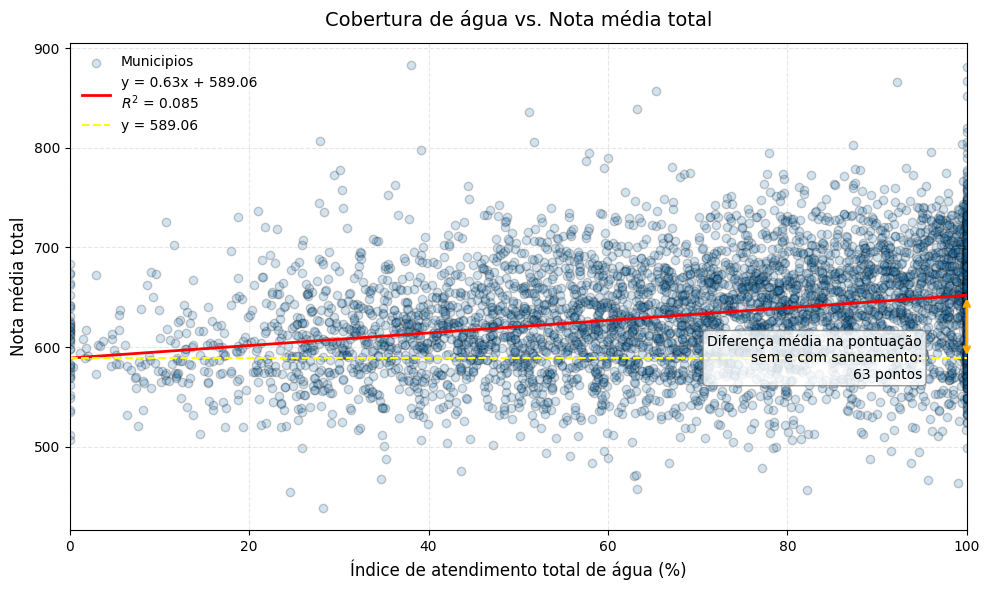

In [19]:
coluna_notas = {
    "SOMA_NOTAS_POR_MORADOR": "Nota média total",
}

for nota in coluna_notas:
    plot_scatter(
        df_final_morador,
        x="INDICE_ATENDIMENTO_TOTAL_AGUA",
        y=nota,
        ylabel=coluna_notas[nota],
    )

### Análise
Analisando o resultado obtido, a diferença entre os alunos de maior desempenho e menor desempenho é de 60 pontos, condizente com algumas pesquisas feitas pelo grupo como [neste link](https://tratabrasil.org.br/enem-ausencia-de-saneamento-influencia-na-nota-media-dos-estudantes-que-realizam-a-prova/) e [neste link](https://www.poder360.com.br/opiniao/enem-e-saneamento-ausencia-do-basico-prejudica-estudantes/).

# Q2. Municípios com altas perdas na distribuição de água têm menor taxa de comparecimento ao exame?


In [20]:
df_q2 = df.copy()
df_q2 = df_q2[df_q2.CO_MUNICIPIO_ESC != 0]
df_q2 = df_q2[df_q2.IN_TREINEIRO == 0]

df_q2["NAO_COMPARECEU_PELO_MENOS_1_DIA"] = (
    (df_q2.TP_PRESENCA_LC == 0)
    | (df_q2.TP_PRESENCA_CH == 0)
    | (df_q2.TP_PRESENCA_CN == 0)
    | (df_q2.TP_PRESENCA_MT == 0)
)

df_q2_group = (
    df_q2[df_q2.NAO_COMPARECEU_PELO_MENOS_1_DIA]
    .groupby(["CO_MUNICIPIO_ESC", "NO_MUNICIPIO_ESC"])
    .agg(
        NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT=(
            "NAO_COMPARECEU_PELO_MENOS_1_DIA",
            "sum",
        ),
        TOTAL=("NU_INSCRICAO", "count"),
    )
    .reset_index()
)

df_q2_group["TAXA_FALTA"] = (
    df_q2_group["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"] / df_q2_group["TOTAL"]
) * 100

df_q2_merged = df_q2_group.merge(
    df_saneamento, left_on="CO_MUNICIPIO_ESC", right_on="ID_MUNICIPIO"
).drop(columns=["ANO", "ID_MUNICIPIO"])[
    df_q2_group.columns.to_list() + ["INDICE_PERDA_DISTRIBUICAO_AGUA"]
]

df_q2_merged = df_q2_merged[df_q2_merged.INDICE_PERDA_DISTRIBUICAO_AGUA >= 80]

df_q2_merged.head()

,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT,TOTAL,TAXA_FALTA,INDICE_PERDA_DISTRIBUICAO_AGUA
16,1100205.0,Porto Velho,1434,1434,100.0,84.01
69,1200609.0,Tarauacá,61,61,100.0,80.87
72,1300029.0,Alvarães,140,140,100.0,83.16
121,1400233.0,Caroebe,15,15,100.0,82.03
125,1400456.0,Pacaraima,13,13,100.0,82.73


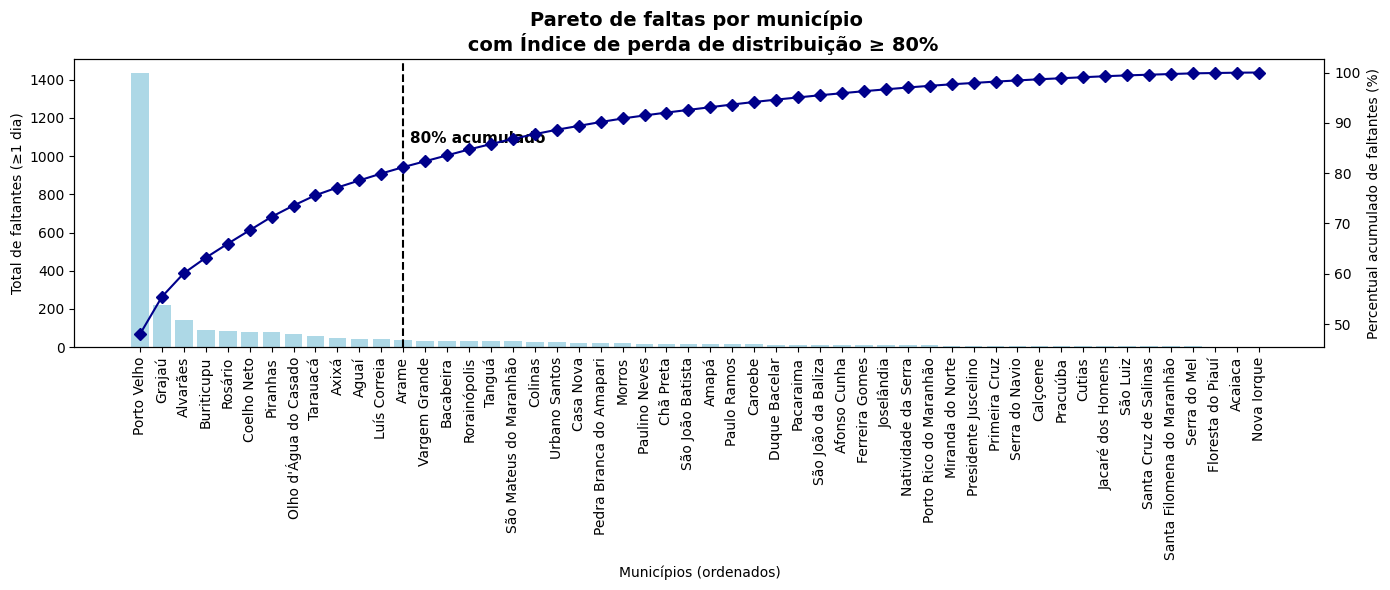

In [21]:
df_plot = df_q2_merged[
    ["NO_MUNICIPIO_ESC", "NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"]
].copy()
df_plot = df_plot.sort_values("NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT", ascending=False)
df_plot["CUMULATIVE_PERCENT"] = (
    df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"].cumsum()
    / df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"].sum()
) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    df_plot["NO_MUNICIPIO_ESC"],
    df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"],
    color="lightblue",
)
ax.set_ylabel("Total de faltantes (≥1 dia)")
ax.set_xlabel("Municípios (ordenados)")

idx_80 = df_plot["CUMULATIVE_PERCENT"].ge(80).idxmax()
x_80 = df_plot.index.get_loc(idx_80)

ymax = ax.get_ylim()[1]

ax.axvline(x=x_80, linestyle="--", color="black")
ax.text(
    x_80 + 0.3,
    ymax * 0.7,
    r"80% acumulado",
    va="bottom",
    ha="left",
    fontdict={"size": 11, "weight": "bold"},
)

ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot["NO_MUNICIPIO_ESC"], rotation=90)

ax2 = ax.twinx()
ax2.plot(
    df_plot["NO_MUNICIPIO_ESC"],
    df_plot["CUMULATIVE_PERCENT"],
    marker="D",
    linestyle="-",
    color="darkblue",
)
ax2.set_ylabel("Percentual acumulado de faltantes (%)")

plt.title(
    "Pareto de faltas por município \n com Índice de perda de distribuição ≥ 80%",
    fontsize=14,
    fontdict={"weight": "bold"},
)
plt.tight_layout()
plt.show()

In [22]:
df_q2[df_q2.NO_MUNICIPIO_ESC == "Porto Velho"].shape[0]

2958

Retirando outlier Porto Velho

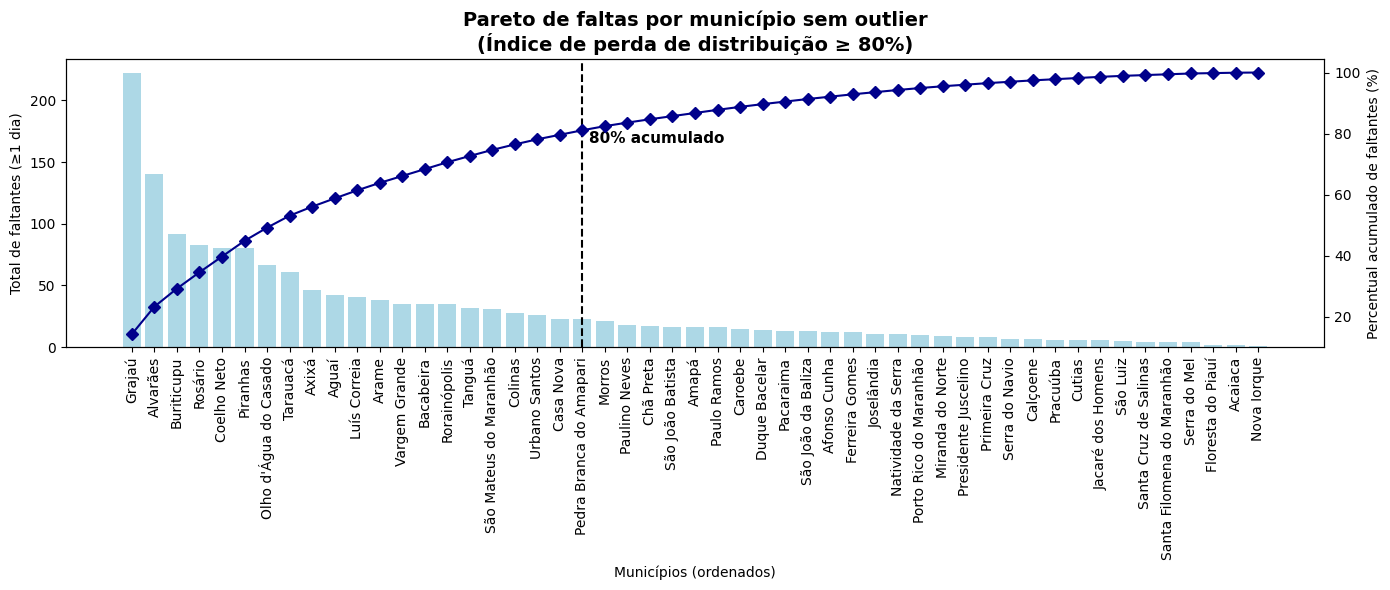

In [23]:
df_plot = df_q2_merged[df_q2_merged.NO_MUNICIPIO_ESC != "Porto Velho"][
    ["NO_MUNICIPIO_ESC", "NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"]
].copy()
df_plot = df_plot.sort_values("NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT", ascending=False)
df_plot["CUMULATIVE_PERCENT"] = (
    df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"].cumsum()
    / df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"].sum()
) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    df_plot["NO_MUNICIPIO_ESC"],
    df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"],
    color="lightblue",
)
ax.set_ylabel("Total de faltantes (≥1 dia)")
ax.set_xlabel("Municípios (ordenados)")

idx_80 = df_plot["CUMULATIVE_PERCENT"].ge(80).idxmax()
x_80 = df_plot.index.get_loc(idx_80)

ymax = ax.get_ylim()[1]

ax.axvline(x=x_80, linestyle="--", color="black")
ax.text(
    x_80 + 0.3,
    ymax * 0.7,
    r"80% acumulado",
    va="bottom",
    ha="left",
    fontdict={"size": 11, "weight": "bold"},
)

ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot["NO_MUNICIPIO_ESC"], rotation=90)

ax2 = ax.twinx()
ax2.plot(
    df_plot["NO_MUNICIPIO_ESC"],
    df_plot["CUMULATIVE_PERCENT"],
    marker="D",
    linestyle="-",
    color="darkblue",
)
ax2.set_ylabel("Percentual acumulado de faltantes (%)")

plt.title(
    "Pareto de faltas por município sem outlier\n(Índice de perda de distribuição ≥ 80%)",
    fontsize=14,
    fontdict={"weight": "bold"},
)
plt.tight_layout()
plt.show()

### Análise
Analisando o resultado obtido, as cidades com alta perda de distribuição de algo também são cidades que concentram a maior parte das faltas no ENEM, condizende com a matéria [deste link](https://g1.globo.com/ro/rondonia/noticia/2021/01/18/rondonia-e-o-estado-com-mais-abstencoes-no-enem-feito-em-meio-a-pandemia-645percent-faltaram.ghtml).

# Q3. Existe uma diferença estatisticamente significativa na média das notas de Matemática do ENEM entre os alunos de municípios com índice de atendimento total de água acima da mediana nacional e aqueles de municípios com índice abaixo da mediana?

In [24]:
df_q3 = df.copy()
df_q3_saneamento = df_saneamento.copy()
df_q3 = df_q3[df_q3["CO_MUNICIPIO_ESC"] != 0]
df_q3 = df_q3[df_q3["IN_TREINEIRO"] == 0]
df_q3 = df_q3[df_q3["TP_STATUS_REDACAO"] == 1]
df_q3 = df_q3[df_q3["TP_PRESENCA_CN"] == 1]
df_q3 = df_q3[df_q3["TP_PRESENCA_CH"] == 1]
df_q3 = df_q3[df_q3["TP_PRESENCA_LC"] == 1]
df_q3 = df_q3[df_q3["TP_PRESENCA_MT"] == 1]

df_merged = pd.merge(
    df_q3,
    df_q3_saneamento,
    left_on="CO_MUNICIPIO_ESC",
    right_on="ID_MUNICIPIO",
    how="inner",
)

mediana_agua = df_merged["INDICE_ATENDIMENTO_TOTAL_AGUA"].median()
print(f"Mediana do Índice de Atendimento Total de Água: {mediana_agua:.2f}")

grupo_acima_mediana = df_merged[
    df_merged["INDICE_ATENDIMENTO_TOTAL_AGUA"] > mediana_agua
]["NU_NOTA_MT"]
grupo_abaixo_mediana = df_merged[
    df_merged["INDICE_ATENDIMENTO_TOTAL_AGUA"] <= mediana_agua
]["NU_NOTA_MT"]

print(f"\nAlunos em municípios acima da mediana: {len(grupo_acima_mediana)}")
print(f"Alunos em municípios abaixo/igual à mediana: {len(grupo_abaixo_mediana)}")

t_stat, p_value = stats.ttest_ind(
    grupo_acima_mediana, grupo_abaixo_mediana, equal_var=False, nan_policy="omit"
)

print(f"\nEstatística T: {t_stat:.4f}")
print(f"Valor-p: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(
        "\nConclusão: Rejeita-se a hipótese nula. Há uma diferença estatisticamente significativa nas médias."
    )
else:
    print(
        "\nConclusão: Não se rejeita a hipótese nula. Não há evidência de diferença significativa nas médias."
    )

Mediana do Índice de Atendimento Total de Água: 95.97

Alunos em municípios acima da mediana: 259411
Alunos em municípios abaixo/igual à mediana: 262122

Estatística T: 119.9224
Valor-p: 0.0000

Conclusão: Rejeita-se a hipótese nula. Há uma diferença estatisticamente significativa nas médias.

Alunos em municípios acima da mediana: 259411
Alunos em municípios abaixo/igual à mediana: 262122

Estatística T: 119.9224
Valor-p: 0.0000

Conclusão: Rejeita-se a hipótese nula. Há uma diferença estatisticamente significativa nas médias.


## Análise
A média das notas de Matemática dos alunos de municípios com melhor acesso à água foi significativamente maior do que a dos alunos de municípios com pior acesso. Isso sugere que o acesso ao saneamento básico, especialmente à água, pode estar associado a melhores desempenhos em matemática no ENEM. 

# Q4. Existe uma associação estatística entre o tipo de abastecimento de água na residência do aluno (conforme Q008 do questionário socioeconômico do ENEM) e o fato de o município ter um índice de atendimento total de água acima ou abaixo da média nacional?

In [25]:
df_q4 = df.copy()
df_saneamento_q4 = df_saneamento.copy()
df_q4.dropna(subset=["Q008"], inplace=True)

df_merged = pd.merge(
    df_q4,
    df_saneamento_q4,
    left_on="CO_MUNICIPIO_ESC",
    right_on="ID_MUNICIPIO",
    how="inner",
)

df_merged["Agua_Canalizada"] = df_merged["Q008"].apply(
    lambda x: "Sim" if x in ["B", "C", "D", "E"] else "Não"
)

media_agua = df_merged["INDICE_ATENDIMENTO_TOTAL_AGUA"].mean()
print(f"Média do Índice de Atendimento Total de Água: {media_agua:.2f}")

df_merged["Nivel_Agua_Municipio"] = df_merged["INDICE_ATENDIMENTO_TOTAL_AGUA"].apply(
    lambda x: "Acima da Média" if x > media_agua else "Abaixo ou Igual"
)

tabela_contingencia = pd.crosstab(
    df_merged["Agua_Canalizada"], df_merged["Nivel_Agua_Municipio"]
)

print("\nTabela de Contingência:")
print(tabela_contingencia)

chi2, p_value, dof, expected = stats.chi2_contingency(tabela_contingencia)

print(f"\nEstatística Qui-Quadrado: {chi2:.4f}")
print(f"Valor-p: {p_value:.4f}")
print(f"Graus de Liberdade: {dof}")

alpha = 0.05
if p_value < alpha:
    print(
        "\nConclusão: Rejeita-se a hipótese nula. Há uma associação estatisticamente significativa entre as variáveis."
    )
else:
    print(
        "\nConclusão: Não se rejeita a hipótese nula. Não há evidência de associação significativa entre as variáveis."
    )

Média do Índice de Atendimento Total de Água: 83.72

Tabela de Contingência:
Nivel_Agua_Municipio  Abaixo ou Igual  Acima da Média
Agua_Canalizada                                      
Não                              4377            1933
Sim                            287411          588553

Estatística Qui-Quadrado: 3780.5259
Valor-p: 0.0000
Graus de Liberdade: 1

Conclusão: Rejeita-se a hipótese nula. Há uma associação estatisticamente significativa entre as variáveis.


## Análise

O teste de associação mostrou que existe uma relação estatisticamente significativa entre o tipo de abastecimento de água informado pelos alunos e o nível de acesso à água do município. Estes dados são provenientes do próprio questionário estatístico aplicado aos alunos. Isso indica que o tipo de abastecimento de água pode ser um indicador importante do acesso ao saneamento básico e, consequentemente, do desempenho no ENEM.

# Q5. Comparando os municípios com os 25% melhores e os 25% piores índices de tratamento de esgoto, como se comportam os intervalos de confiança de 95% para a média das notas de Matemática? A sobreposição entre esses intervalos sugere uma disparidade significativa no desempenho em matemática associada a este nível de saneamento?

In [26]:
df_q5 = df.copy()
df_q5.dropna(subset=["NU_NOTA_MT"], inplace=True)
df_saneamento_q5 = df_saneamento.copy()
df_merged = pd.merge(
    df_q5,
    df_saneamento_q5,
    left_on="CO_MUNICIPIO_ESC",
    right_on="ID_MUNICIPIO",
    how="inner",
)


q1_esgoto = df_merged["INDICE_ATENDIMENTO_ESGOTO_AGUA"].quantile(
    0.25
)
q3_esgoto = df_merged["INDICE_ATENDIMENTO_ESGOTO_AGUA"].quantile(
    0.75
)

print(f"Quartil Inferior (Q1) do Índice de Tratamento de Esgoto: {q1_esgoto:.2f}")
print(f"Quartil Superior (Q3) do Índice de Tratamento de Esgoto: {q3_esgoto:.2f}\n")

notas_q1 = df_merged[
    df_merged["INDICE_ATENDIMENTO_ESGOTO_AGUA"] <= q1_esgoto
]["NU_NOTA_MT"]
notas_q4 = df_merged[
    df_merged["INDICE_ATENDIMENTO_ESGOTO_AGUA"] >= q3_esgoto
]["NU_NOTA_MT"]

print(f"Número de alunos no Quartil 1 (Piores): {len(notas_q1)}")
print(f"Número de alunos no Quartil 4 (Melhores): {len(notas_q4)}\n")


def calcular_ic_media(dados, conf_level=0.95):
    if len(dados) < 2:
        return (np.nan, np.nan)
    mean = dados.mean()
    std_err = stats.sem(dados)
    degrees_freedom = len(dados) - 1
    interval = stats.t.interval(conf_level, degrees_freedom, loc=mean, scale=std_err)
    return interval


ic_q1 = calcular_ic_media(notas_q1)
ic_q4 = calcular_ic_media(notas_q4)

print(
    f"IC 95% para Média de Matemática (Quartil 1 - Piores): ({ic_q1[0]:.2f}, {ic_q1[1]:.2f})"
)
print(
    f"IC 95% para Média de Matemática (Quartil 4 - Melhores): ({ic_q4[0]:.2f}, {ic_q4[1]:.2f})\n"
)


if not np.isnan(ic_q1[0]) and not np.isnan(ic_q4[0]):
    media_q1 = notas_q1.mean()
    media_q4 = notas_q4.mean()
    print(f"Média (Q1): {media_q1:.2f} | Média (Q4): {media_q4:.2f}")
    print(f"Diferença nas médias: {abs(media_q4 - media_q1):.2f} pontos")

Quartil Inferior (Q1) do Índice de Tratamento de Esgoto: 38.68
Quartil Superior (Q3) do Índice de Tratamento de Esgoto: 93.45

Número de alunos no Quartil 1 (Piores): 117002
Número de alunos no Quartil 4 (Melhores): 117317

IC 95% para Média de Matemática (Quartil 1 - Piores): (511.43, 512.70)
IC 95% para Média de Matemática (Quartil 4 - Melhores): (582.36, 583.75)

Média (Q1): 512.06 | Média (Q4): 583.06
Diferença nas médias: 70.99 pontos
Número de alunos no Quartil 1 (Piores): 117002
Número de alunos no Quartil 4 (Melhores): 117317

IC 95% para Média de Matemática (Quartil 1 - Piores): (511.43, 512.70)
IC 95% para Média de Matemática (Quartil 4 - Melhores): (582.36, 583.75)

Média (Q1): 512.06 | Média (Q4): 583.06
Diferença nas médias: 70.99 pontos


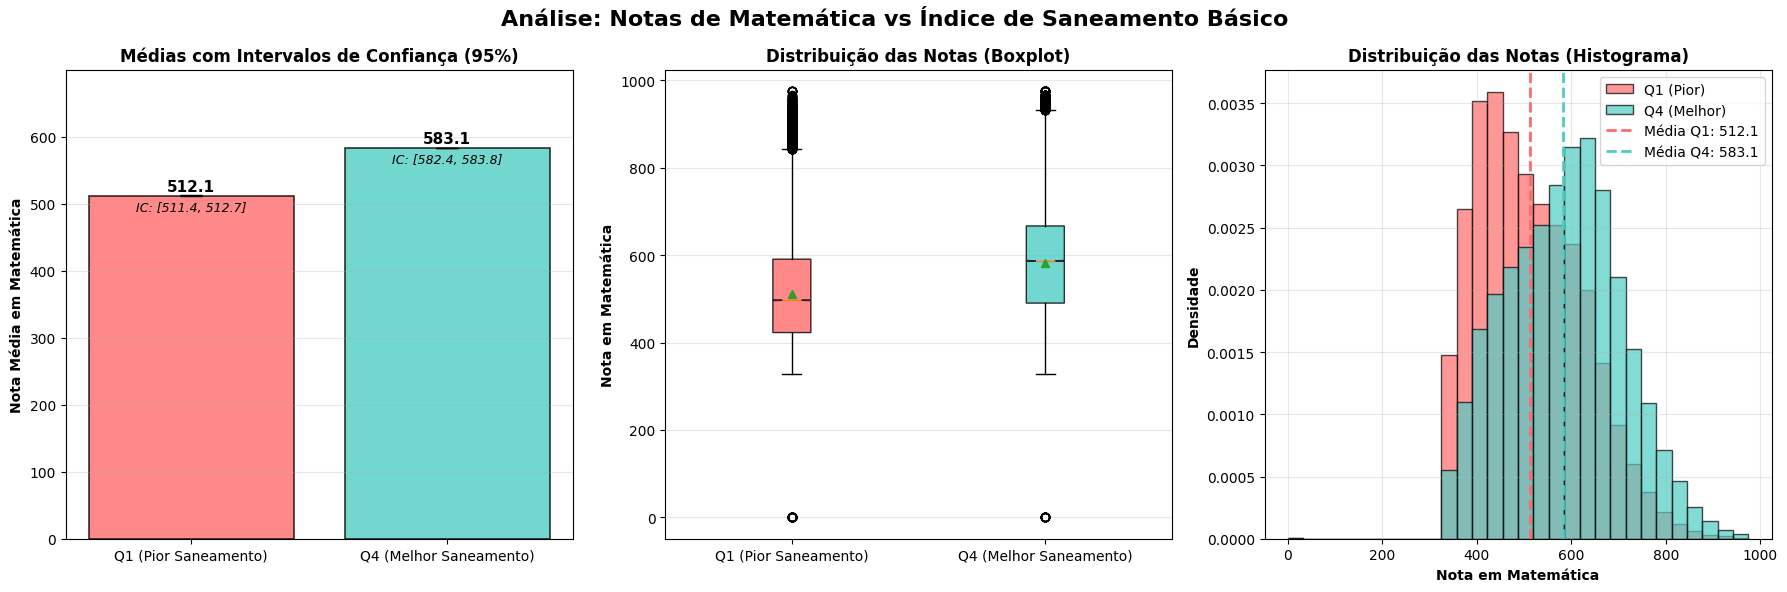

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análise: Notas de Matemática vs Índice de Saneamento Básico',
             fontsize=16, fontweight='bold', y=0.98)

# 1. Gráfico de barras com intervalos de confiança
medias = [notas_q1.mean(), notas_q4.mean()]
ic_inferior = [ic_q1[0], ic_q4[0]]
ic_superior = [ic_q1[1], ic_q4[1]]
erro_baixo = [medias[i] - ic_inferior[i] for i in range(2)]
erro_alto = [ic_superior[i] - medias[i] for i in range(2)]

labels = ['Q1 (Pior Saneamento)', 'Q4 (Melhor Saneamento)']
colors = ['#ff6b6b', '#4ecdc4']

bars = ax1.bar(labels, medias, yerr=[erro_baixo, erro_alto],
               capsize=8, color=colors, alpha=0.8,
               edgecolor='black', linewidth=1.2)

for i, (v, bar) in enumerate(zip(medias, bars)):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 3,
             f'{v:.1f}', ha='center', va='bottom',
             fontweight='bold', fontsize=11)

    ax1.text(bar.get_x() + bar.get_width()/2, v - 8,
             f'IC: [{ic_inferior[i]:.1f}, {ic_superior[i]:.1f}]',
             ha='center', va='top', fontsize=9, style='italic')

ax1.set_ylabel('Nota Média em Matemática', fontweight='bold')
ax1.set_title('Médias com Intervalos de Confiança (95%)', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(medias) * 1.2)

# 2. Boxplots comparativos (FIXED: changed 'labels' to 'tick_labels')
box_data = [notas_q1, notas_q4]
box_plot = ax2.boxplot(box_data, tick_labels=labels, patch_artist=True,
                       notch=True, showmeans=True)

for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax2.set_ylabel('Nota em Matemática', fontweight='bold')
ax2.set_title('Distribuição das Notas (Boxplot)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Histogramas
ax3.hist(notas_q1, bins=30, alpha=0.7, label='Q1 (Pior)',
         color=colors[0], density=True, edgecolor='black')
ax3.hist(notas_q4, bins=30, alpha=0.7, label='Q4 (Melhor)',
         color=colors[1], density=True, edgecolor='black')

ax3.axvline(medias[0], color=colors[0], linestyle='--', linewidth=2,
           label=f'Média Q1: {medias[0]:.1f}')
ax3.axvline(medias[1], color=colors[1], linestyle='--', linewidth=2,
           label=f'Média Q4: {medias[1]:.1f}')

ax3.set_xlabel('Nota em Matemática', fontweight='bold')
ax3.set_ylabel('Densidade', fontweight='bold')
ax3.set_title('Distribuição das Notas (Histograma)', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Análise
Os intervalos de confiança das médias de matemática para os grupos de melhor e pior saneamento não se sobrepõem, indicando uma diferença estatisticamente significativa entre eles. Isso demonstra a disparidade em relação aquelas que possuem e não possuem saneamento: alunos de municípios com maior índice de tratamento de esgoto apresentam médias de matemática bastante superiores em relação aos alunos de municípios com piores índices.

### **Conclusão** 🏗️


# **Referências**

[Arquivos auxiliares do SNIS](https://storage.googleapis.com/basedosdados-dev/auxiliary_files/br_mdr_snis/municipio_agua_esgoto/br_mdr_snis_auxiliary_files.zip)

[Micro dados do ENEM](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem)

[Curso de ciência de dados IMT](https://github.com/Rogerio-mack/IMT_CD_2025)


# **Apêndice: Vídeo, GitHub e Datafólio**

Publique (YouTube ou qualquer outro de acesso público) um vídeo explicativo apresentando o seu trabalho em no máximo 4min. Foque na relevância do problema e nos resultados obtidos. Salve em um GitHub público seu projeto (o notebook Python, dados, Datafólio).

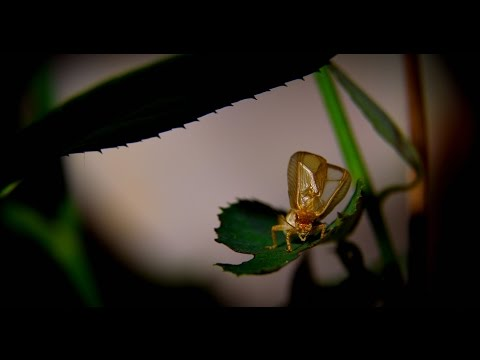

In [28]:
from IPython.display import YouTubeVideo
YouTubeVideo('ssSCGwy_Qfo') # substitua pelo seu vídeo

In [32]:
#@markdown
#@title **Avaliação**
Completo = 10 #@param {type:"slider", min:0, max:10, step:1}
#@markdown São apresentadas 5-6 perguntas e empregadas estatísticas descritivas, seleções simples e múltiplas, agrupamentos e transformações dos dados.
Relevancia = 9 #@param {type:"slider", min:0, max:10, step:1}
#@markdown O tema é abordado corretamente e as perguntas e análises pertinentes ao problema.
Tecnicas = 10 #@param {type:"slider", min:0, max:10, step:1}
#@markdown As técnicas de gadas estatísticas dos dados, seleções, agrupamentos e transformações são corretamente aplicadas
Apresentacao = 5 #@param {type:"slider", min:0, max:10, step:1}
#@markdown A apresentação dos resultados é clara e objetiva
Conclusao = 3 #@param {type:"slider", min:0, max:10, step:1}
#@markdown As conclusões são justificadas e relevantes
Bonus = 0.5 #@param {type:"slider", min:0, max:1, step:0.5}
#@markdown A critério do professor por inovações na abordagem e no uso de técnicas de Análise de Dados

#@markdown ---
#@markdown ### Apresentação
Datafolio = 0 #@param {type:"slider", min:0, max:10, step:1}
Video = 0 #@param {type:"slider", min:0, max:10, step:1}





In [33]:
#@markdown # **Nota Final**
Nota1 = Completo + Relevancia + Tecnicas + Apresentacao + Conclusao
Nota2 = Datafolio + Apresentacao

nota = (Nota1 + Nota2) / 7 + Bonus

nota = Nota1 / 5 + Bonus

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_tia = []
lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_tia.append(lista[0]); lista_nome.append(lista[1].upper())")

alunos['tia'] = lista_tia
alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 7.9



,tia,nome,nota
0,Enzo Yuji Sakamoto,21.00210-0,7.9
1,João Vitor Choueri Branco,21.01075-7,7.9
2,Pedro Henrique de Sousa Matumoto,21.00784-5,7.9
3,Rafael Rubio Carnes,20.00611-0,7.9
4,Vitor Guirão Soller,21.01444-2,7.9


O resultado reforça a importância de políticas públicas voltadas para a ampliação do acesso à água tratada como forma de promover a equidade educacional.
Em resumo, municípios com melhor saneamento apresentam desempenho superior em matemática, evidenciando a relação entre infraestrutura básica e resultados educacionais.